In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
tasks = pd.read_csv("../data/processed/tasks_processed.csv")
employees = pd.read_csv("../data/processed/employees_processed.csv")
projects = pd.read_csv("../data/processed/projects_processed.csv")
employee_performance = pd.read_csv("../data/processed/employee_performance_processed.csv")

In [6]:
print(tasks.columns.tolist())

['Task_ID', 'Task_Title', 'Task_Description', 'Category', 'Priority', 'Status', 'Project_Name', 'Module', 'Sprint', 'Story_Points', 'Created_Date', 'Due_Date', 'Estimated_Hours', 'Actual_Hours', 'Assigned_To', 'Environment', 'Severity', 'Labels', 'SLA_Hours', 'Completion_Status']


Task Priority Distribution

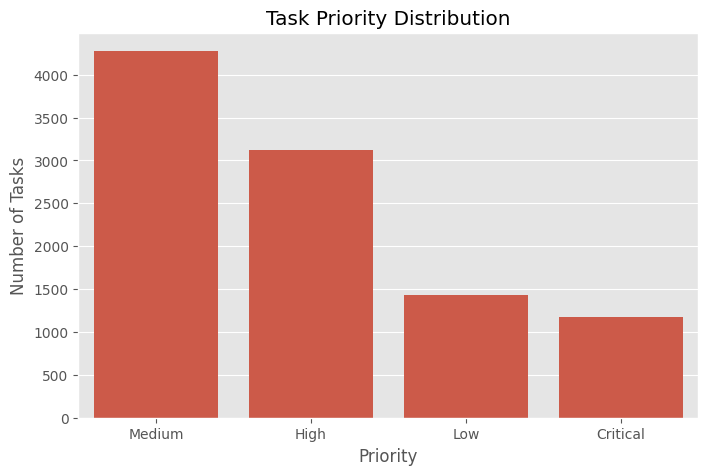

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tasks,
    x="Priority",
    order=tasks["Priority"].value_counts().index
)

plt.title("Task Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tasks")
plt.savefig("../outputs/charts/task_priority.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Task Status Distribution

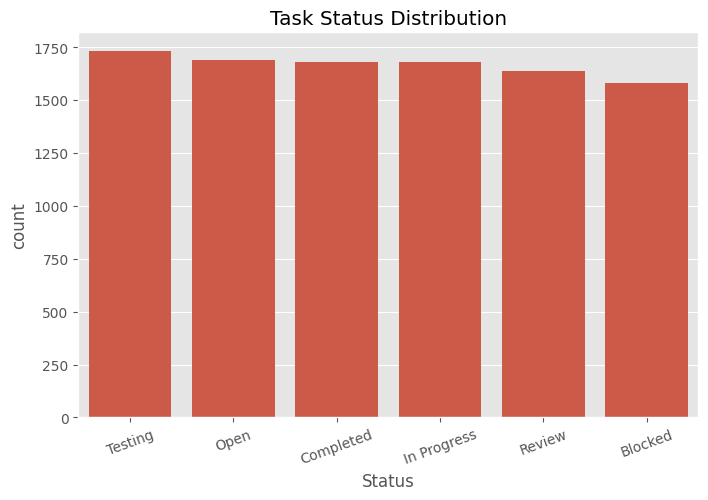

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tasks,
    x="Status",
    order=tasks["Status"].value_counts().index
)

plt.xticks(rotation=20)

plt.title("Task Status Distribution")
plt.savefig("../outputs/charts/task_status.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Tasks by Category

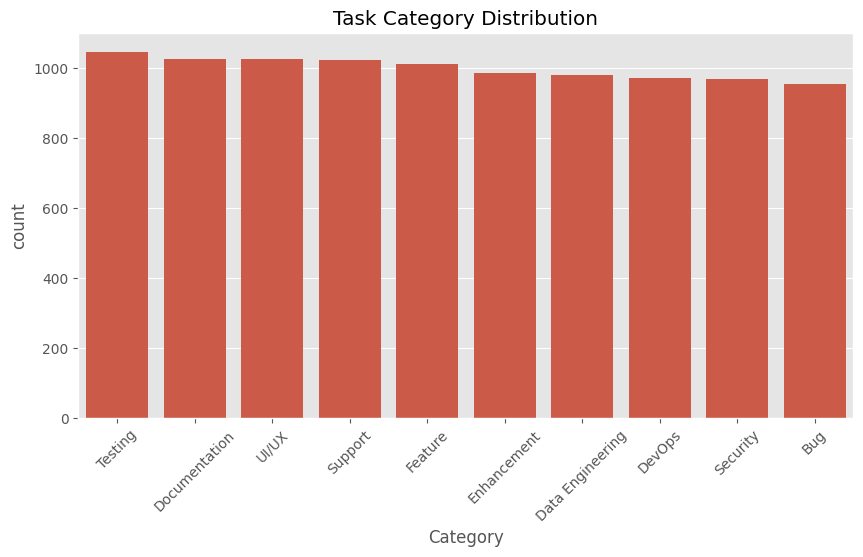

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=tasks,
    x="Category",
    order=tasks["Category"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Task Category Distribution")
plt.savefig("../outputs/charts/task_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Tasks per Employee (Top 10)

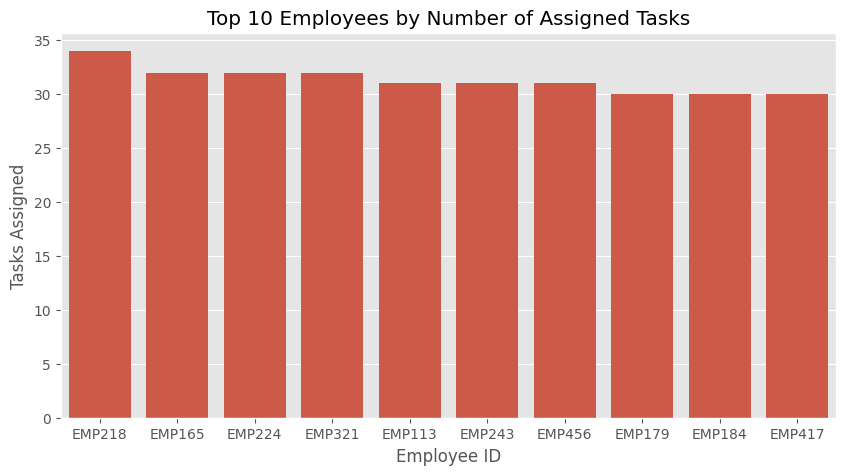

In [14]:
top_employee = tasks["Assigned_To"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_employee.index.astype(str),
    y=top_employee.values
)

plt.title("Top 10 Employees by Number of Assigned Tasks")
plt.xlabel("Employee ID")
plt.ylabel("Tasks Assigned")
plt.savefig("../outputs/charts/top_employee_tasks.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Severity Distribution

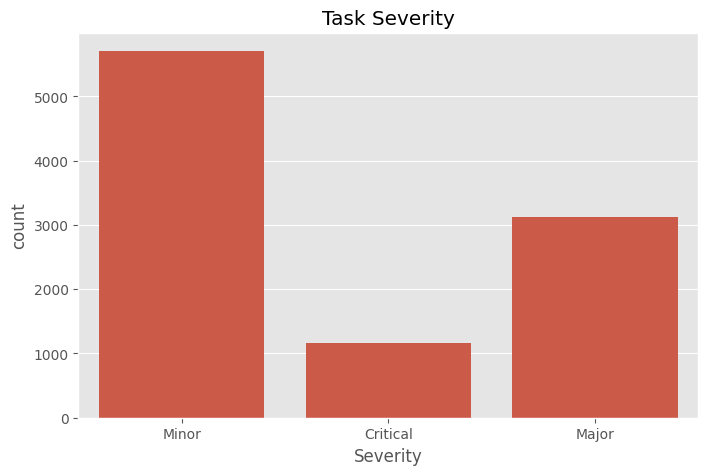

In [15]:
plt.figure(figsize=(8,5))


sns.countplot(
    data=tasks,
    x="Severity"
)

plt.title("Task Severity")

plt.savefig("../outputs/charts/task_severity.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Department-wise Employees

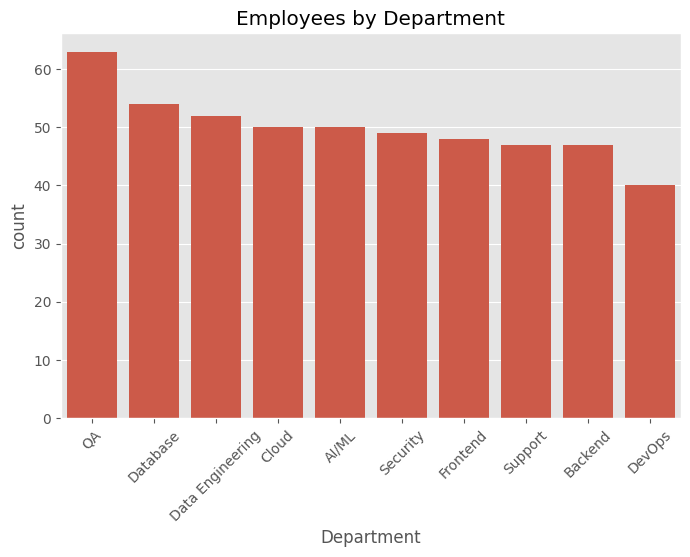

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=employees,
    x="Department",
    order=employees["Department"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Employees by Department")
plt.savefig("../outputs/charts/employee_department.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Employee Experience Distribution

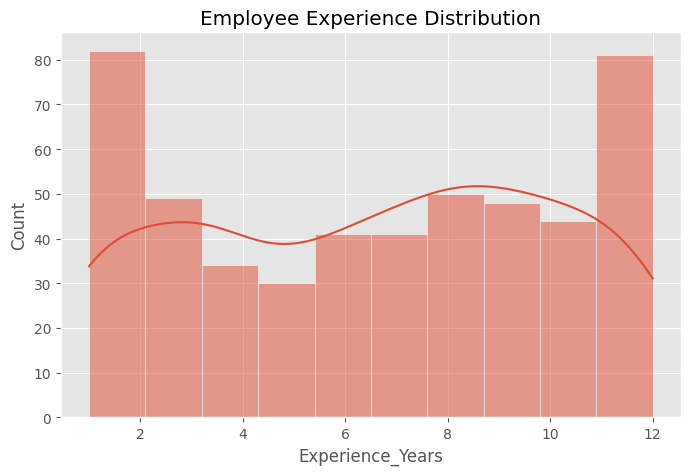

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    employees["Experience_Years"],
    bins=10,
    kde=True
)

plt.title("Employee Experience Distribution")
plt.savefig("../outputs/charts/employee_experience.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Average Employee Rating

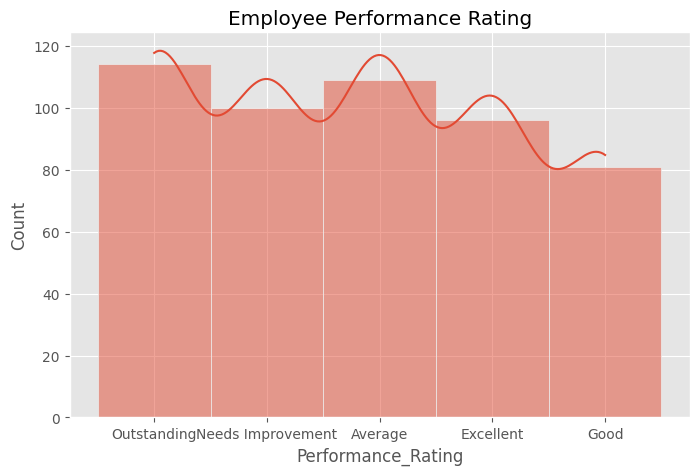

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    employee_performance["Performance_Rating"],
    bins=10,
    kde=True
)

plt.title("Employee Performance Rating")
plt.savefig("../outputs/charts/employee_performance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Story Points Distribution

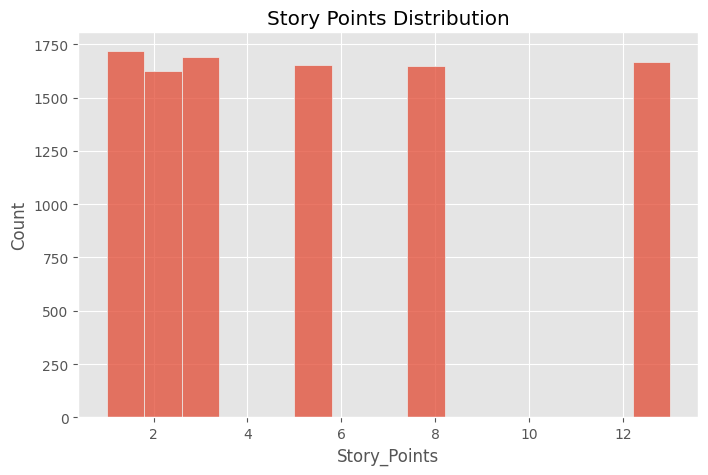

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(tasks["Story_Points"], bins=15)

plt.title("Story Points Distribution")

plt.savefig("../outputs/charts/story_points.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

    Estimated Hours Distribution

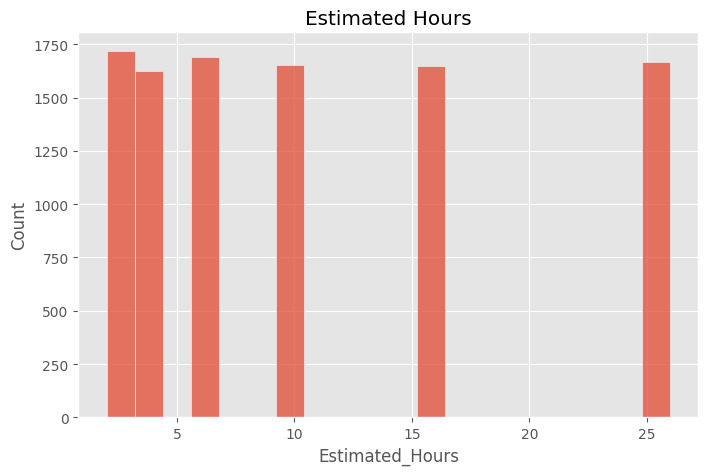

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(tasks["Estimated_Hours"], bins=20)

plt.title("Estimated Hours")

plt.savefig("../outputs/charts/estimated_hours.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Actual Hours Distribution

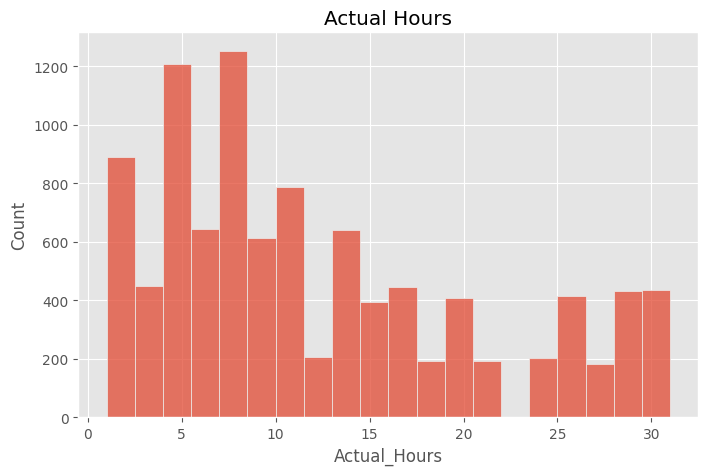

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(tasks["Actual_Hours"], bins=20)

plt.title("Actual Hours")

plt.savefig("../outputs/charts/actual_hours.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Tasks per Project

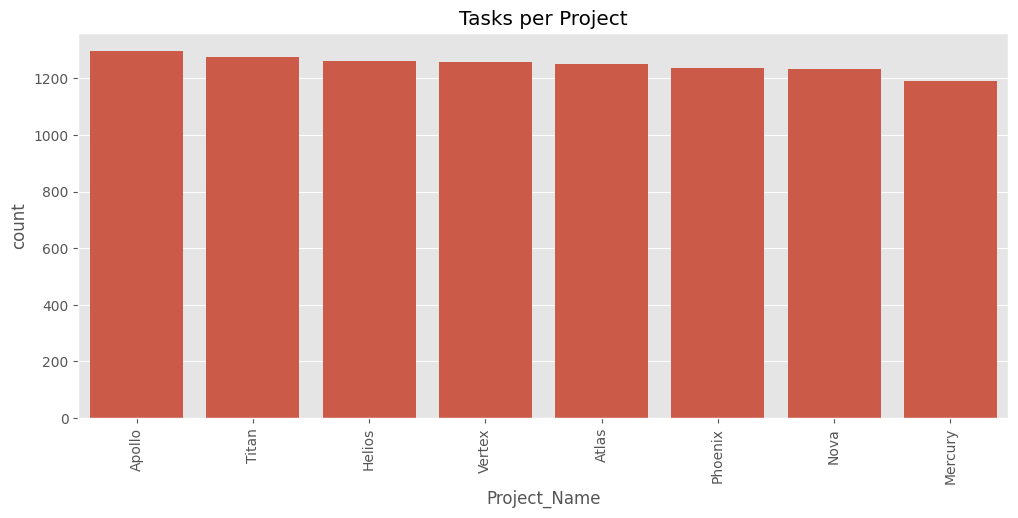

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=tasks,
    x="Project_Name",
    order=tasks["Project_Name"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Tasks per Project")

plt.savefig("../outputs/charts/project_tasks.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Tasks per Sprint

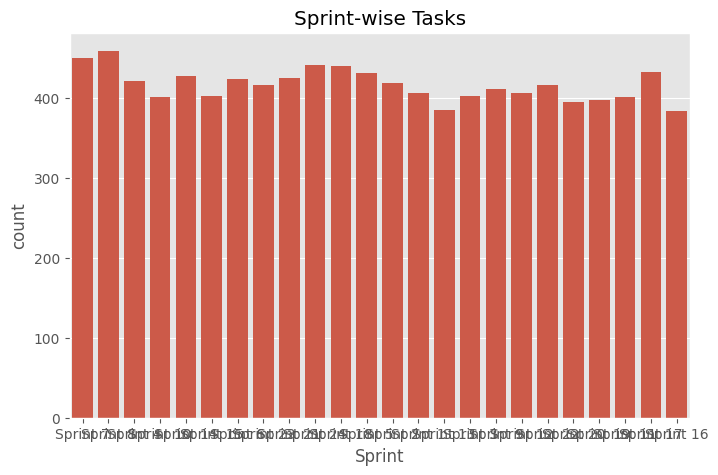

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tasks,
    x="Sprint"
)

plt.title("Sprint-wise Tasks")

plt.savefig("../outputs/charts/sprint_tasks.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

Project Status

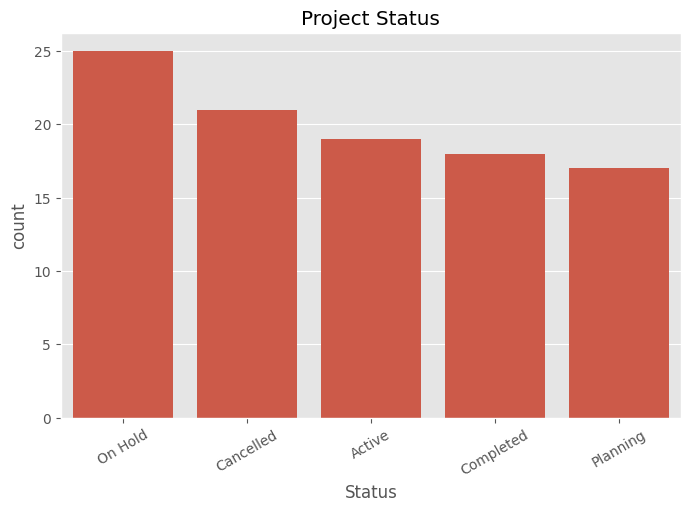

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=projects,
    x="Status",
    order=projects["Status"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Project Status")
plt.savefig("../outputs/charts/Project_Status.png")

plt.show()

Correlation Heatmap

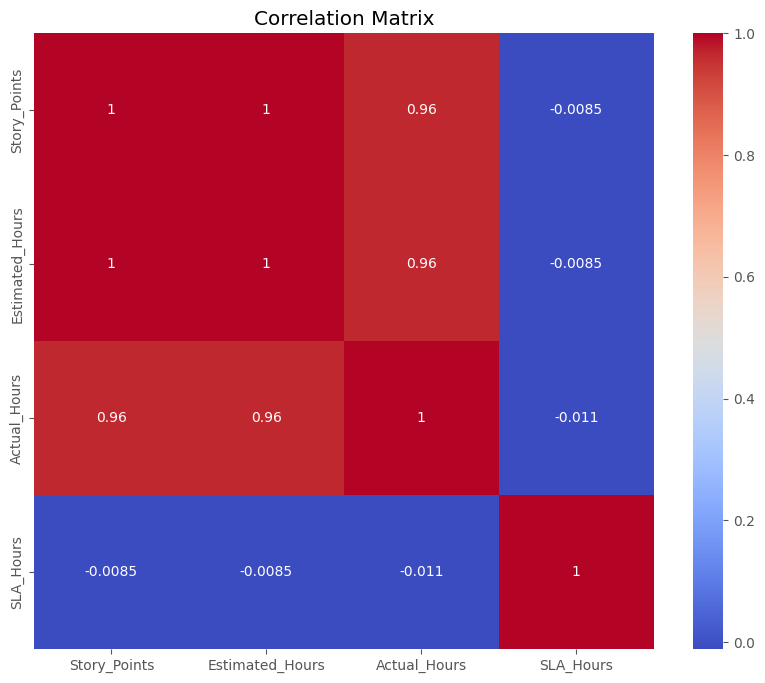

In [25]:
numeric = tasks.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.savefig("../outputs/charts/correlation.png")

plt.show()

Task Creation Trend

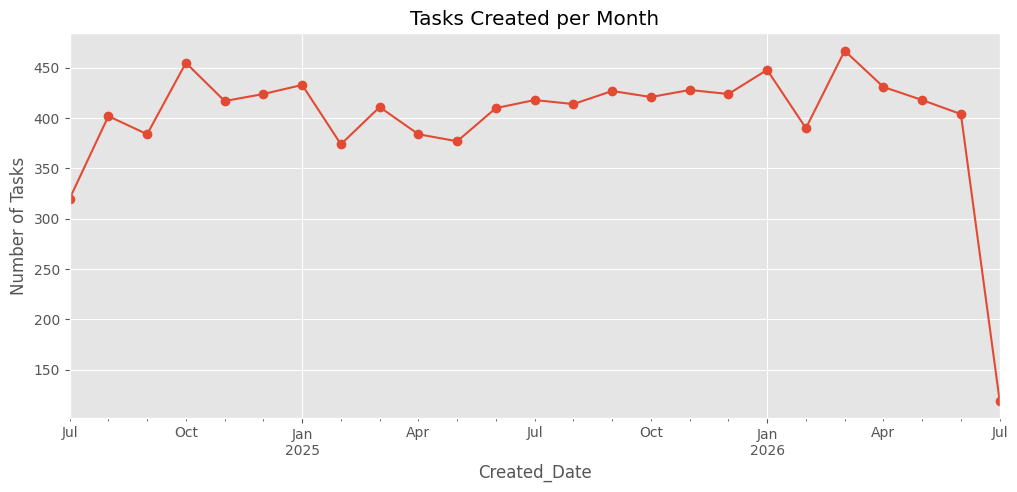

In [23]:
tasks["Created_Date"] = pd.to_datetime(tasks["Created_Date"])

monthly = tasks.groupby(
    tasks["Created_Date"].dt.to_period("M")
).size()

monthly.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Tasks Created per Month")

plt.ylabel("Number of Tasks")
plt.savefig("../outputs/charts/task_priority.png")

plt.show()